# 03 - Feature selection: top 40 of 77 - CIC-IDS-2017

In [1]:
DATASET = "cic2017"
FT_ROOT = None
TOP_K = 40

In [2]:
import sys
from pathlib import Path

def _find_nb_common():
    for cand in [Path.cwd(), *Path.cwd().parents]:
        for c in (cand, cand / "notebooks"):
            if (c / "nb_common.py").exists():
                return c
    raise FileNotFoundError("nb_common.py not found relative to " + str(Path.cwd()))
sys.path.insert(0, str(_find_nb_common()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import nb_common as nbc
from ids import config
from ids.schema import CANONICAL_COLUMNS
from ids.features.importance import rank_by_rf_importance, select_top_k

P = nbc.ft_paths(DATASET, FT_ROOT)
log = nbc.setup_logging(P.logs / "03_feature_selection.log", "nb03")

with nbc.timed(log, "load clean.parquet"):
    df = pd.read_parquet(P.data / "clean.parquet")
X, y = df[CANONICAL_COLUMNS], df["y"].to_numpy()
log.info("%d rows, %d features, %d classes", len(X), X.shape[1], len(np.unique(y)))

2026-07-06 10:32:19,625 INFO nb03: START load clean.parquet
2026-07-06 10:32:21,008 INFO nb03: END   load clean.parquet (1.4s)
2026-07-06 10:32:21,948 INFO nb03: 2520798 rows, 77 features, 15 classes


## 1. Stratified 70/30 split

In [3]:
idx = np.arange(len(X))
train_idx, test_idx = train_test_split(
    idx, test_size=0.30, stratify=y, random_state=config.RANDOM_STATE)
np.savez_compressed(P.splits / "70_30_indices.npz", train_idx=train_idx, test_idx=test_idx)
log.info("70/30 split: %d train / %d test (stratified, seed=%d)",
         len(train_idx), len(test_idx), config.RANDOM_STATE)

2026-07-06 10:32:23,895 INFO nb03: 70/30 split: 1764558 train / 756240 test (stratified, seed=42)


## 2. Rank all 77 features on the training portion

In [4]:
with nbc.timed(log, f"RandomForest importance on {len(train_idx)} training rows"):
    ranking = rank_by_rf_importance(X.iloc[train_idx], y[train_idx])
rank_df = pd.DataFrame(ranking, columns=["feature", "importance"])
rank_df.insert(0, "rank", range(1, len(rank_df) + 1))
rank_df.to_csv(P.features / "importance_ranking.csv", index=False)
rank_df.head(15)

2026-07-06 10:32:23,900 INFO nb03: START RandomForest importance on 1764558 training rows
2026-07-06 10:34:46,088 INFO nb03: END   RandomForest importance on 1764558 training rows (142.2s)


,rank,feature,importance
0,1,pkt_len_var,0.060520
1,2,bwd_pkt_len_mean,0.052036
2,3,bwd_seg_size_avg,0.047504
3,4,bwd_pkt_len_std,0.044767
4,5,totlen_bwd_pkts,0.044605
5,6,pkt_len_std,0.040591
6,7,pkt_size_avg,0.037910
7,8,bwd_pkt_len_max,0.037885
8,9,subflow_bwd_byts,0.035369
9,10,totlen_fwd_pkts,0.031315


## 3. Freeze the top 40

2026-07-06 10:34:46,112 INFO nb03: top 40 features cover 91.3% of total importance


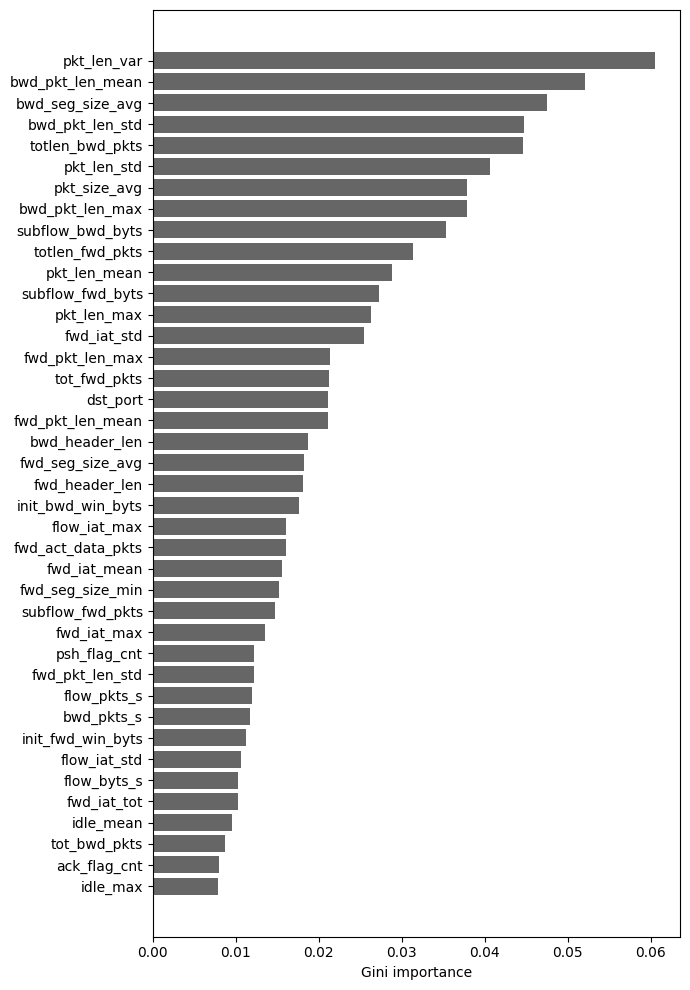

['pkt_len_var',
 'bwd_pkt_len_mean',
 'bwd_seg_size_avg',
 'bwd_pkt_len_std',
 'totlen_bwd_pkts',
 'pkt_len_std',
 'pkt_size_avg',
 'bwd_pkt_len_max',
 'subflow_bwd_byts',
 'totlen_fwd_pkts',
 'pkt_len_mean',
 'subflow_fwd_byts',
 'pkt_len_max',
 'fwd_iat_std',
 'fwd_pkt_len_max',
 'tot_fwd_pkts',
 'dst_port',
 'fwd_pkt_len_mean',
 'bwd_header_len',
 'fwd_seg_size_avg',
 'fwd_header_len',
 'init_bwd_win_byts',
 'flow_iat_max',
 'fwd_act_data_pkts',
 'fwd_iat_mean',
 'fwd_seg_size_min',
 'subflow_fwd_pkts',
 'fwd_iat_max',
 'psh_flag_cnt',
 'fwd_pkt_len_std',
 'flow_pkts_s',
 'bwd_pkts_s',
 'init_fwd_win_byts',
 'flow_iat_std',
 'flow_byts_s',
 'fwd_iat_tot',
 'idle_mean',
 'tot_bwd_pkts',
 'ack_flag_cnt',
 'idle_max']

In [5]:
top40 = select_top_k(ranking, TOP_K)
cum_importance = float(rank_df.head(TOP_K)["importance"].sum())
nbc.save_json({
    "dataset": DATASET,
    "k": TOP_K,
    "selected": top40,
    "cumulative_importance": round(cum_importance, 4),
    "fitted_on": "train side of the stratified 70/30 split only (no test leakage)",
    "random_state": config.RANDOM_STATE,
}, P.features / "top40.json")
log.info("top %d features cover %.1f%% of total importance", TOP_K, 100 * cum_importance)

fig, ax = plt.subplots(figsize=(7, 10))
head = rank_df.head(TOP_K).iloc[::-1]
ax.barh(head["feature"], head["importance"], color="0.4")
ax.set_xlabel("Gini importance")
fig.tight_layout()
fig.savefig(P.features / "top40_importance.png", dpi=150)
plt.show()
top40